# LGBM_threhold=0.15

## 0. 라이브러리 및 데이터셋 불러오기 

### [1] 라이브러리불러오기

In [3]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import re

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold

# sklearn 버전에 따라 StratifiedGroupKFold가 없을 수도 있어서 예외 처리
try:
    from sklearn.model_selection import StratifiedGroupKFold
    USE_STRATIFIED_GROUP = True
except ImportError:
    from sklearn.model_selection import GroupKFold
    USE_STRATIFIED_GROUP = False



### [2] 데이터 파일 불러오기

In [ ]:
#1. 학습시킬 원본 데이터셋 불러오기
df_origin = pd.read_csv('YOUR_DATASET.csv')
print('===df_origin.shape===',df_origin.shape)
print(df_origin.columns.to_list)

df_origin.head(10)

===df_origin.shape=== (203551, 46)
<bound method IndexOpsMixin.tolist of Index(['BSI', 'BSI_max', 'BSI_mean', 'BSI_min', 'BSI_slope', 'BSI_std',
       'Z_BSI', 'Z_BSI_max', 'Z_BSI_mean', 'Z_Battery_Current',
       'Z_Battery_Voltage', 'Z_Delta_I', 'Z_Delta_V', 'Z_Joule_Heating_Stress',
       'Z_Thermal_Stress', 'abs_power', 'ambient_temp', 'battery_temp',
       'battery_temp_mean', 'current', 'current_max_abs',
       'current_status_label', 'delta_i', 'delta_i_max_abs', 'delta_p',
       'delta_t', 'delta_t_temp', 'delta_v', 'delta_v_max_abs', 'di_dt',
       'dp_dt', 'dt_dt', 'dv_dt', 'is_near_risk_zone', 'is_risk_zone',
       'joule_heating_stress', 'power', 'power_max_abs',
       'rolling_abs_power_70min', 'source', 'temp_diff', 'temp_diff_max',
       'temp_diff_mean', 'thermal_stress', 'vehicle_id', 'voltage'],
      dtype='str')>


,BSI,BSI_max,BSI_mean,BSI_min,BSI_slope,BSI_std,Z_BSI,Z_BSI_max,Z_BSI_mean,Z_Battery_Current,...,power,power_max_abs,rolling_abs_power_70min,source,temp_diff,temp_diff_max,temp_diff_mean,thermal_stress,vehicle_id,voltage
0,0.203308,0.203308,0.203308,0.203308,0.000000,0.000000,-0.408666,-0.408666,-0.408666,0.010670,...,-7411.025664,7411.025664,7411.025664,TripB01.csv,-1.5,-1.5,-1.5,-0.822973,VehicleB_001,388.80000
1,0.290179,0.290179,0.246743,0.203308,0.086870,0.061427,-0.285469,-0.285469,-0.347067,0.063353,...,-6354.396405,7411.025664,6940.798033,TripB01.csv,-1.5,-1.5,-1.5,-0.922579,VehicleB_001,388.90975
2,0.269382,0.290179,0.254290,0.203308,0.033037,0.045359,-0.314962,-0.285469,-0.336365,0.069155,...,-6237.813892,7411.025664,6655.951293,TripB01.csv,-1.5,-1.5,-1.5,-0.979941,VehicleB_001,388.90981
3,0.249723,0.290179,0.253148,0.203308,0.011845,0.037106,-0.342842,-0.285469,-0.337985,0.068372,...,-6253.387552,7411.025664,6498.702836,TripB01.csv,-1.5,-1.5,-1.5,-1.011200,VehicleB_001,388.90000
4,0.306364,0.306364,0.263791,0.203308,0.016566,0.039988,-0.262515,-0.262515,-0.322891,0.079209,...,-6034.993810,7411.025664,6394.849759,TripB01.csv,-1.5,-1.5,-1.5,-1.032979,VehicleB_001,388.85996
5,0.240293,0.306364,0.259875,0.203308,0.006109,0.037030,-0.356215,-0.262515,-0.328445,0.069332,...,-6232.327188,7411.025664,6343.621793,TripB01.csv,-1.5,-1.5,-1.5,-1.042204,VehicleB_001,388.79001
6,0.270055,0.306364,0.261329,0.203308,0.004909,0.034022,-0.314007,-0.262515,-0.326382,0.069345,...,-6230.458270,7411.025664,6298.469456,TripB01.csv,-1.5,-1.5,-1.5,-1.051204,VehicleB_001,388.68991
7,0.264658,0.306364,0.261745,0.203308,0.003550,0.031520,-0.321662,-0.262515,-0.325792,0.071838,...,-6178.965388,7411.025664,6275.215801,TripB01.csv,-1.5,-1.5,-1.5,-1.056090,VehicleB_001,388.60000
8,0.303078,0.306364,0.266338,0.203308,0.005241,0.032545,-0.267174,-0.262515,-0.319279,0.070636,...,-6201.497295,7411.025664,6309.607293,TripB01.csv,-1.5,-1.5,-1.5,-1.049115,VehicleB_001,388.50000
9,1.922176,1.922176,0.431922,0.203308,0.094130,0.524520,2.028990,2.028990,-0.084452,-0.328537,...,-14099.655087,14099.655087,6512.128467,TripB01.csv,-1.5,-1.5,-1.5,-0.942470,VehicleB_001,385.35261


### [3] 모델학습에 필요한 컬럼만 선택하여 df_clean에 담기

In [ ]:
df_clean = df_origin[['voltage',
                      'current',
                      'battery_temp',
                      'ambient_temp',
                      'delta_v',
                      'delta_i',
                      'temp_diff',
                      'joule_heating_stress',
                      'rolling_abs_power_70min',
                      'thermal_stress',
                      'temp_diff_mean',
                      'vehicle_id',
                      'current_status_label'
]]

print('===df_clean.shape===',df_clean.shape)

df_clean

===df_clean.shape=== (203551, 13)


,voltage,current,battery_temp,ambient_temp,delta_v,delta_i,temp_diff,joule_heating_stress,rolling_abs_power_70min,thermal_stress,temp_diff_mean,vehicle_id,current_status_label
0,388.800000,-19.061280,7.0,8.5,0.000000,0.000000,-1.5,363.332395,7411.025664,-0.822973,-1.5,VehicleB_001,0.0
1,388.909750,-16.339000,7.0,8.5,-0.030510,0.403820,-1.5,266.962921,6940.798033,-0.922579,-1.5,VehicleB_001,0.0
2,388.909810,-16.039230,7.0,8.5,-0.030380,0.201890,-1.5,257.256899,6655.951293,-0.979941,-1.5,VehicleB_001,0.0
3,388.900000,-16.079680,7.0,8.5,0.000000,-0.150010,-1.5,258.556109,6498.702836,-1.011200,-1.5,VehicleB_001,0.0
4,388.859960,-15.519710,7.0,8.5,0.050000,-0.349960,-1.5,240.861398,6394.849759,-1.032979,-1.5,VehicleB_001,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
203546,-0.834907,0.478907,0.0,0.0,0.032160,0.066747,0.0,0.229352,2.586034,-0.024776,0.0,VehicleA_002,0.0
203547,-0.834907,0.479574,0.0,0.0,0.000000,0.000667,0.0,0.229992,2.586017,-0.024715,0.0,VehicleA_002,0.0
203548,-0.810169,0.485582,0.0,0.0,0.024738,0.006007,0.0,0.235790,2.585996,-0.024113,0.0,VehicleA_002,0.0
203549,-0.810169,0.482912,0.0,0.0,0.000000,-0.002670,0.0,0.233204,2.585976,-0.024392,0.0,VehicleA_002,0.0


### [4] 결측치 확인하기

In [ ]:
# 전처리 과정에서 결측치 전처리 완료됨.
print(df_clean.isna().sum())

voltage                    0
current                    0
battery_temp               0
ambient_temp               0
delta_v                    0
delta_i                    0
temp_diff                  0
joule_heating_stress       0
rolling_abs_power_70min    0
thermal_stress             0
temp_diff_mean             0
vehicle_id                 0
current_status_label       0
dtype: int64


### [5] train/test 차량이 겹치지 않도록 분리

In [33]:
# df_final_clean에서 차량종류 확인하기
print('===차량종류===', df_clean['vehicle_id'].unique())

===차량종류=== <StringArray>
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11',
 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22',
 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33',
 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44',
 'A45', 'A46', 'A47', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08',
 'B09', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19',
 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30',
 'B31', 'B32', 'B33', 'B34', 'B35', 'B36', 'B37', 'B38', 'B39', 'B40', 'B41',
 'B42', 'B43', 'B44', 'B45', 'B46', 'B47', 'B48']
Length: 95, dtype: str


In [34]:
from sklearn.model_selection import train_test_split

# 차량 목록 추출
vehicle_df = df_clean[['vehicle_id']].drop_duplicates().copy()

# 80:20 분리
train_vids, test_vids = train_test_split(
                            vehicle_df['vehicle_id'],
                            test_size=0.2,
                            random_state=42
                        )

# 최종 분리
df_train = df_clean[df_clean['vehicle_id'].isin(train_vids)].copy()
df_test  = df_clean[df_clean['vehicle_id'].isin(test_vids)].copy()

# 검증
print('=====겹치는 차량: ',sorted(set(df_train['vehicle_id']) & set(df_test['vehicle_id'])))  
print('=====train set에 있는 차량 개수: ',df_train['vehicle_id'].nunique())
print('=====train set에 있는 차량 목록: ',df_train['vehicle_id'].unique())
print('=====test set에 있는 차량: ', df_test['vehicle_id'].nunique())
print('=====test set에 있는 차량 목록: ',df_test['vehicle_id'].unique())

=====겹치는 차량:  []
=====train set에 있는 차량 개수:  76
=====train set에 있는 차량 목록:  <StringArray>
['A02', 'A03', 'A04', 'A06', 'A07', 'A08', 'A09', 'A10', 'A12', 'A14', 'A15',
 'A16', 'A17', 'A18', 'A20', 'A21', 'A22', 'A24', 'A25', 'A26', 'A28', 'A30',
 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A42', 'A44',
 'A45', 'A47', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B10', 'B11',
 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B23',
 'B24', 'B25', 'B28', 'B29', 'B30', 'B31', 'B32', 'B33', 'B34', 'B36', 'B37',
 'B39', 'B40', 'B41', 'B42', 'B43', 'B44', 'B45', 'B46', 'B47', 'B48']
Length: 76, dtype: str
=====test set에 있는 차량:  19
=====test set에 있는 차량 목록:  <StringArray>
['A01', 'A05', 'A11', 'A13', 'A19', 'A23', 'A27', 'A29', 'A40', 'A41', 'A43',
 'A46', 'B01', 'B09', 'B22', 'B26', 'B27', 'B35', 'B38']
Length: 19, dtype: str


# 1. 모델링

### [0] 기본 설정

In [ ]:
# train set 설정
df = df_train.copy()

# 파라미터
TARGET_COL = 'current_status_label' # 정답 컬럼
GROUP_COL = 'vehicle_id' # 그룹 컬럼(차량 이름), 
N_SPLITS = 5 # cv교차검증시 필요함. cv안하면 필요없는 변수
RANDOM_STATE = 42
threshold = 0.15 

df.shape

(176026, 13)

### [0-1] 특수문자 에러 방지
LightGBM은 특수문자 에러가 자주 일어남.

In [10]:
def clean_feature_name(col):
    col = str(col).strip()

    replacements = {
        '%': 'pct',
        '°C': 'degC',
        '°': 'deg',
        '[': '_',
        ']': '',
        '(': '_',
        ')': '',
        '/': '_',
        '\\': '_',
        '-': '_',
        '.': '_',
        ' ': '_',
        ',': '_',
        ':': '_',
        ';': '_',
        '{': '_',
        '}': '_',
        '"': '',
        "'": '',
        '__': '_'
    }

    for old, new in replacements.items():
        col = col.replace(old, new)

    col = re.sub(r'[^A-Za-z0-9_]', '', col)
    col = re.sub(r'_+', '_', col)
    col = col.strip('_')

    # 빈 문자열 방지
    if col == '':
        col = 'feature'

    # 숫자로 시작하면 접두사 추가
    if col[0].isdigit():
        col = 'f_' + col

    return col


def make_unique_columns(columns):
    seen = {}
    new_cols = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")

    return new_cols


### [1] 제외할 컬럼 : 

TARGET_COL: 정답컬럼

GROUP_COL: 차량 id 컬럼(vehicle_id)

In [ ]:
# 정답 레이블, 차량 id 컬럼(vehicle_id)
manual_drop = [
    TARGET_COL,
    GROUP_COL
]

leakage_cols = set()

for col in df.columns:
    col_low = col.lower()

    if col in manual_drop:
        leakage_cols.add(col)
        continue


# 실제 존재하는 컬럼만 유지
leakage_cols = sorted([c for c in leakage_cols if c in df.columns])

print("=" * 60)
print('제외할 컬럼 확인',leakage_cols[:100]) 
print("=" * 60)
print("현재 train shape:", df.shape)

제외할 컬럼 확인 ['current_status_label', 'vehicle_id']
현재 train shape: (176026, 13)


### [3] X / y / groups 구성

In [12]:
y = df[TARGET_COL].copy()
groups = df[GROUP_COL].copy()

X = df.drop(columns=leakage_cols, errors='ignore').copy()

print("현재 train shape:", X.shape)
# print("원본 X 컬럼:", X.columns.tolist())
# print("최종 X shape:", X.shape)
# print("최종 feature 수:", X.shape[1])

x_selected_cols = pd.Series(X.columns).reset_index(drop=True).T
print("====남아있는 컬럼====")
print(x_selected_cols)

현재 train shape: (176026, 11)
====남아있는 컬럼====
0                     voltage
1                     current
2                battery_temp
3                ambient_temp
4                     delta_v
5                     delta_i
6                   temp_diff
7        joule_heating_stress
8     rolling_abs_power_70min
9              thermal_stress
10             temp_diff_mean
dtype: str


### [3] LightGBM용 컬럼명 정리 : 특수문자 에러 방지 

In [13]:
original_cols = X.columns.tolist()
clean_cols = [clean_feature_name(c) for c in original_cols]
clean_cols = make_unique_columns(clean_cols)

col_map = dict(zip(original_cols, clean_cols))
reverse_col_map = dict(zip(clean_cols, original_cols))

X = X.rename(columns=col_map)

print("\n====컬럼명 변경====")
for old, new in list(col_map.items())[:30]:
    print(f"{old}  -->  {new}")

print("\n정리 후 X shape:", X.shape)

x_final_cols = pd.DataFrame({
    '컬럼명원본': original_cols,
    '변경된컬럼명': X.columns,
    'dtype': X.dtypes
}).reset_index(drop=True)

print("\n====최종 컬럼 정보====")
print(x_final_cols.head(20))


====컬럼명 변경====
voltage  -->  voltage
current  -->  current
battery_temp  -->  battery_temp
ambient_temp  -->  ambient_temp
delta_v  -->  delta_v
delta_i  -->  delta_i
temp_diff  -->  temp_diff
joule_heating_stress  -->  joule_heating_stress
rolling_abs_power_70min  -->  rolling_abs_power_70min
thermal_stress  -->  thermal_stress
temp_diff_mean  -->  temp_diff_mean

정리 후 X shape: (176026, 11)

====최종 컬럼 정보====
                      컬럼명원본                   변경된컬럼명    dtype
0                   voltage                  voltage  float64
1                   current                  current  float64
2              battery_temp             battery_temp  float64
3              ambient_temp             ambient_temp  float64
4                   delta_v                  delta_v  float64
5                   delta_i                  delta_i  float64
6                 temp_diff                temp_diff  float64
7      joule_heating_stress     joule_heating_stress  float64
8   rolling_abs_power_70min 

### [4] x_final결측치 확인

In [14]:
print("\n====결측치====")
print(X.isna().sum().sort_values(ascending=False).head(20))



====결측치====
voltage                    0
current                    0
battery_temp               0
ambient_temp               0
delta_v                    0
delta_i                    0
temp_diff                  0
joule_heating_stress       0
rolling_abs_power_70min    0
thermal_stress             0
temp_diff_mean             0
dtype: int64


### [7] CV splitter

In [15]:
if USE_STRATIFIED_GROUP:
    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    split_iter = cv.split(X, y, groups)
    print("\nStratifiedGroupKFold 사용")
else:
    cv = GroupKFold(n_splits=N_SPLITS)
    split_iter = cv.split(X, y, groups)
    print("\nGroupKFold 사용 (sklearn 버전 확인 필요)")



StratifiedGroupKFold 사용


### [8] LightGBM CV

In [ ]:
oof_pred = np.zeros(len(df), dtype=int)
fold_scores = []
feature_importance_list = []

for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
    X_train, X_valid = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
    y_train, y_valid = y.iloc[tr_idx].copy(), y.iloc[va_idx].copy()

    train_groups = groups.iloc[tr_idx]
    valid_groups = groups.iloc[va_idx]

    overlap = set(train_groups) & set(valid_groups)

    print(f"\n{'='*70}")
    print(f"Fold {fold}")
    print(f"train rows: {len(tr_idx):,}, valid rows: {len(va_idx):,}")
    # print(f"train vehicle 수: {train_groups.nunique()}, valid vehicle 수: {valid_groups.nunique()}")
    # print(f"겹치는 vehicle_id 수: {len(overlap)}")

    print("\ntrain label 비율")
    print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

    print("\nvalid label 비율")
    print((y_valid.value_counts(normalize=True).sort_index() * 100).round(2))

    model = lgb.LGBMClassifier(
        objective='multiclass', 
        num_class=y.nunique(), # NORMAL=0 / WARNING=1 / DANGER=2
        n_estimators=800, # 트리개수. 많을수록 복잡하고 오래 학습함.
        learning_rate=0.03, # 한번에 얼마나 조금씩 배울지.
        num_leaves=18,  # 트리 하나가 얼마나 복잡할지.
        subsample=0.8, # 행 데이터를 80%만 랜덤으로 학습. 과적합 방지용
        colsample_bytree=0.8, # 컬럼을 80%만 랜덤으로 학습. 과적합 방지용
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='multi_logloss',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    proba = model.predict_proba(X_valid)
    classes = model.classes_
    DANGER_IDX = np.where(classes == 2)[0][0]   # danger 라벨이 2라는 가정
    DANGER_THRESHOLD = 0.15

    pred = []
    for p in proba:
        if p[DANGER_IDX] >= DANGER_THRESHOLD:
            pred.append(classes[DANGER_IDX])
        else:
            pred.append(classes[int(np.argmax(p))])

    pred = np.array(pred)
    oof_pred[va_idx] = pred

    fold_f1 = f1_score(y_valid, pred, average='macro')
    fold_scores.append(fold_f1)

    print(f"\nFold {fold} Macro F1: {fold_f1:.4f}")

    fi = pd.DataFrame({
        'feature_clean': X.columns,
        'importance': model.feature_importances_,
        'gain_importance': model.booster_.feature_importance(importance_type='gain'),
        'fold': fold
    })
    fi['feature_original'] = fi['feature_clean'].map(reverse_col_map)

    feature_importance_list.append(fi)




### [9] CV 결과

In [16]:
print("\n" + "=" * 60)
print("CV 결과")
print("Fold별 Macro F1:", [round(s, 4) for s in fold_scores])
print("평균 Macro F1:", round(np.mean(fold_scores), 4))
print("표준편차:", round(np.std(fold_scores), 4))

print("\nOOF Classification Report")
print(classification_report(y, oof_pred, digits=4))

print("\nOOF Confusion Matrix")
print(confusion_matrix(y, oof_pred))

# =========================
# 7. 평균 feature importance
# =========================
fi_all = pd.concat(feature_importance_list, ignore_index=True)

fi_mean = (
    fi_all.groupby('feature_clean', as_index=False)[['importance', 'gain_importance']]
    .mean()
    .sort_values('gain_importance', ascending=False)
)

print("\n평균 Feature Importance Top 30")
print(fi_mean.head(30))


CV 결과
Fold별 Macro F1: [0.7293, 0.8269, 0.6346, 0.7377, 0.705]
평균 Macro F1: 0.7267
표준편차: 0.0618

OOF Classification Report
              precision    recall  f1-score   support

         0.0     0.9785    0.8998    0.9375    131341
         1.0     0.6697    0.5397    0.5977     23181
         2.0     0.5214    0.8870    0.6568     21504

    accuracy                         0.8508    176026
   macro avg     0.7232    0.7755    0.7307    176026
weighted avg     0.8820    0.8508    0.8585    176026


OOF Confusion Matrix
[[118175   4020   9146]
 [  2312  12510   8359]
 [   280   2150  19074]]

평균 Feature Importance Top 30
              feature_clean  importance  gain_importance
3                   delta_i      3304.4     1.893853e+06
9            thermal_stress      1559.0     5.104273e+05
5      joule_heating_stress       399.6     4.985378e+05
4                   delta_v      1773.2     4.322725e+05
6   rolling_abs_power_70min      1552.4     2.383755e+05
2                   current  

### [10] CV feature importance

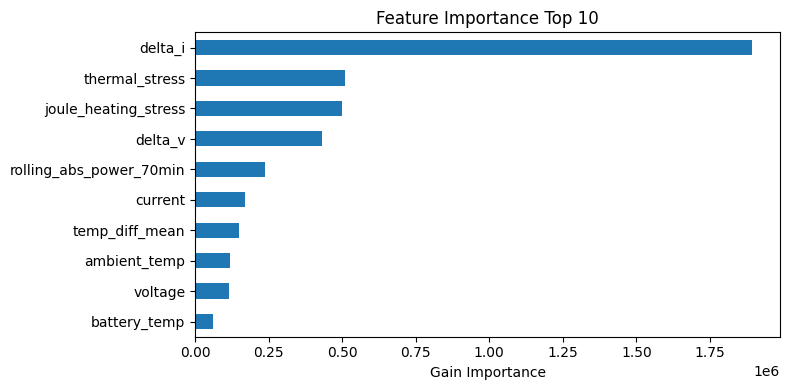

In [17]:
import matplotlib.pyplot as plt

top10 = fi_mean.head(10).sort_values('gain_importance')
top10.plot.barh(x='feature_clean', y='gain_importance', figsize=(8, 4), legend=False)

plt.title('Feature Importance Top 10')
plt.xlabel('Gain Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

### [10] train-test 최종 모델링 후 평가

In [19]:
final_train_df = df_train.copy()
final_test_df = df_test.copy()

X_train_final = final_train_df.drop(columns=leakage_cols, errors='ignore').copy()
y_train_final = final_train_df[TARGET_COL].copy()

X_test_final = final_test_df.drop(columns=leakage_cols, errors='ignore').copy()
y_test_final = final_test_df[TARGET_COL].copy()

# 컬럼명 정리
X_train_final = X_train_final.rename(columns=col_map)
X_test_final = X_test_final.rename(columns=col_map)

# train/test 컬럼 순서 맞추기
X_test_final = X_test_final[X_train_final.columns]

print("final train shape:", X_train_final.shape)
print("final test shape:", X_test_final.shape)
print("겹치는 vehicle 수:", len(set(final_train_df[GROUP_COL]) & set(final_test_df[GROUP_COL])))

final train shape: (176026, 11)
final test shape: (27525, 11)
겹치는 vehicle 수: 0


# 2. 모델 결과

In [ ]:
final_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=y_train_final.nunique(), # NORMAL=0 / WARNING=1 / DANGER=2
    n_estimators=800, # 트리개수. 많을수록 복잡하고 오래 학습함.
    learning_rate=0.03, # 한번에 얼마나 조금씩 배울지.
    num_leaves=18, # 트리 하나가 얼마나 복잡할지.
    min_child_samples=80, # 리프 노드 하나에 있어야하는 최소 샘플 수
    reg_alpha=0.5,  # 규제
    reg_lambda=1.0,
    subsample=0.9, # 행 데이터를 90%만 랜덤으로 학습. 과적합 방지용
    colsample_bytree=0.9, # 컬럼을 90%만 랜덤으로 학습. 과적합 방지용
    random_state=RANDOM_STATE,
    class_weight={0: 1, 1: 3, 2: 4}, # NORMAL=0 / WARNING=1 / DANGER=2 클래스별 가중치
    n_jobs=-1
)

final_model.fit(X_train_final, y_train_final)

proba = final_model.predict_proba(X_test_final)
classes = final_model.classes_

# danger 라벨 인덱스
DANGER_IDX = np.where(classes == 2)[0][0]   # 라벨이 0/1/2일 때
DANGER_THRESHOLD = 0.15

test_pred = []
for p in proba:
    if p[DANGER_IDX] >= DANGER_THRESHOLD:
        test_pred.append(classes[DANGER_IDX])
    else:
        test_pred.append(classes[int(np.argmax(p))])

test_pred = np.array(test_pred)

print("\n" + "=" * 60)
print("Hold-out Test Classification Report")
print(classification_report(y_test_final, test_pred, digits=4))

print("\nHold-out Test Confusion Matrix")
print(confusion_matrix(y_test_final, test_pred))

print("\nHold-out Test Macro F1:", round(f1_score(y_test_final, test_pred, average='macro'), 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2797
[LightGBM] [Info] Number of data points in the train set: 176026, number of used features: 11
[LightGBM] [Info] Start training from score -0.781337
[LightGBM] [Info] Start training from score -1.417188
[LightGBM] [Info] Start training from score -1.204600

Hold-out Test Classification Report
              precision    recall  f1-score   support

         0.0     0.9897    0.8034    0.8869     18372
         1.0     0.6553    0.7817    0.7129      4864
         2.0     0.5435    0.8629    0.6669      4289

    accuracy                         0.8088     27525
   macro avg     0.7295    0.8160    0.7556     27525
weighted avg     0.8611    0.8088    0.8219     27525


Hold-out Test Confusion Matrix
[[14760  1436  2176]
 [  129  3802